# Dynamic Pricing vs Static Pricing — Simulation on Historical Sales

This notebook estimates whether dynamic pricing can increase **sales volume** compared to static pricing for selected popular products.

## What this notebook does
1. Loads historical product sales from `ecommerce.db` (`sales_aggregated`).
2. Fits per-product demand models from historical observations.
3. Estimates price elasticity and filters to products where demand responds to price changes.
4. Simulates two scenarios on historical states (same inventory + calendar):
   - **Static pricing**: fixed median historical price
   - **Dynamic pricing**: adaptive price policy with guardrails
5. Quantifies sales uplift and runs statistical validation (bootstrap CI + paired permutation test).

> Note: This is a counterfactual simulation based on historical data and modeled demand. It is strong evidence, not proof in the strict causal-experimental sense.

In [7]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 100)

DB_PATH = '/home/miko/magister/ecommerce.db'
TOP_N_PRODUCTS = 8
MIN_OBS_PER_PRODUCT = 40
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Notebook configured.')

Notebook configured.


In [8]:
conn = sqlite3.connect(DB_PATH)
query = """
SELECT product_id, date, sales, price, stock
FROM sales_aggregated
WHERE sales IS NOT NULL AND price IS NOT NULL AND stock IS NOT NULL
"""
df = pd.read_sql(query, conn)
conn.close()

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['product_id', 'date']).reset_index(drop=True)

# Basic cleaning
df = df[(df['sales'] >= 0) & (df['price'] > 0) & (df['stock'] >= 0)].copy()


# Time features
df['dow'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['season'] = ((df['month'] % 12) // 3 + 1).astype(int)

print(f'Rows: {len(df):,}')
print(f'Products: {df["product_id"].nunique():,}')
display(df.head())

Rows: 478,846
Products: 645


,product_id,date,sales,price,stock,dow,month,season
0,P0001,2017-01-02,6.0,6.25,195.0,0,1,1
1,P0001,2017-01-03,1.0,6.25,194.0,1,1,1
2,P0001,2017-01-04,2.0,6.25,192.0,2,1,1
3,P0001,2017-01-05,1.0,6.25,191.0,3,1,1
4,P0001,2017-01-06,3.0,6.25,188.0,4,1,1


## Select popular products with enough signal

We choose top products by total sales volume, then keep products with enough observations and non-trivial price variation.

In [9]:
product_stats = (
    df.groupby('product_id')
      .agg(
          total_sales=('sales', 'sum'),
          n_obs=('sales', 'size'),
          price_std=('price', 'std'),
          price_min=('price', 'min'),
          price_max=('price', 'max')
      )
      .reset_index()
)

product_stats['price_std'] = product_stats['price_std'].fillna(0)
eligible = product_stats[(product_stats['n_obs'] >= MIN_OBS_PER_PRODUCT) & (product_stats['price_std'] > 0.01)]
selected_products = (
    eligible.sort_values('total_sales', ascending=False)
            .head(TOP_N_PRODUCTS)['product_id']
            .tolist()
)

df_sel = df[df['product_id'].isin(selected_products)].copy()

print('Selected products:', selected_products)
display(product_stats[product_stats['product_id'].isin(selected_products)].sort_values('total_sales', ascending=False))

Selected products: ['P0103', 'P0438', 'P0364', 'P0051', 'P0131', 'P0569', 'P0333', 'P0590']


,product_id,total_sales,n_obs,price_std,price_min,price_max
92,P0103,881634.0,1092,0.567591,2.610500,4.250000
374,P0438,565348.0,959,0.092440,0.250000,0.500000
315,P0364,277763.0,1092,0.281170,1.000000,1.992248
45,P0051,236744.0,1092,0.147401,0.700000,1.000000
114,P0131,214924.0,1092,0.452785,1.817949,3.250000
490,P0569,192400.0,1092,0.419027,2.562736,4.216794
289,P0333,180100.0,1092,0.495291,1.851887,3.000000
507,P0590,163834.0,1092,0.171225,0.489320,0.950000


In [10]:
# "Customer-like" segmentation na poziomie produktów przy użyciu K-means

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans



# Cechy pseudo-klienckie na poziomie produktu:

# - purchase_frequency: liczba dni z obserwacją sprzedaży

# - basket_size: średnia liczba sztuk sprzedanych dziennie

# - recency_days: ile dni minęło od ostatniej sprzedaży (im mniejsza wartość, tym bardziej "aktywny")



max_date = df['date'].max()

product_features = (

    df.groupby('product_id')

      .agg(

          purchase_frequency=('sales', 'size'),

          basket_size=('sales', 'mean'),

          last_date=('date', 'max'),

      )

      .reset_index()

)



product_features['recency_days'] = (max_date - product_features['last_date']).dt.days.astype(float)

product_features = product_features.drop(columns=['last_date'])



feature_cols = ['purchase_frequency', 'basket_size', 'recency_days']

X = product_features[feature_cols].fillna(0.0).values



scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)



N_SEGMENTS = 3

kmeans = KMeans(n_clusters=N_SEGMENTS, random_state=RANDOM_SEED, n_init=10)

segments = kmeans.fit_predict(X_scaled)



product_features['segment'] = segments



# Mapowanie product_id -> segment (pseudo-customer segment)

PRODUCT_SEGMENT = dict(zip(product_features['product_id'], product_features['segment']))



print("✓ Przeprowadzono segmentację K-means na poziomie produktów (pseudo-klienci)")

display(product_features.head())


✓ Przeprowadzono segmentację K-means na poziomie produktów (pseudo-klienci)


,product_id,purchase_frequency,basket_size,recency_days,segment
0,P0001,1092,2.718864,0.0,0
1,P0002,974,0.049281,0.0,0
2,P0004,898,0.471047,194.0,2
3,P0005,1092,0.653846,0.0,0
4,P0006,511,0.221135,66.0,1


## Fit per-product demand models and estimate elasticity

Modeling assumption:
- Target: `log1p(sales)`
- Key regressor: `log(price)`
- Controls: `log(stock + 1)`, day-of-week, month

The coefficient for `log(price)` is interpreted as approximate own-price elasticity.

In [11]:
# Estymacja elastyczności cenowej popytu metodą log-liniową

import numpy as np

import pandas as pd



elasticity_rows = []



for pid in selected_products:

    dfp = df[df['product_id'] == pid].copy()

    # Minimalna liczba obserwacji i zróżnicowanie cen

    if len(dfp) < MIN_OBS_PER_PRODUCT:

        continue

    if dfp['price'].std() <= 1e-6:

        continue



    # Log-liniowy model: log1p(sales) = alpha + beta * log(price)

    x = np.log(dfp['price'].values)

    y = np.log1p(dfp['sales'].values)



    # Prosta regresja liniowa (OLS) bez dodatkowych kontroli

    beta, alpha = np.polyfit(x, y, 1)



    elasticity_rows.append({

        'product_id': pid,

        'elasticity': float(beta),

        'n_obs': int(len(dfp)),

        'price_std': float(dfp['price'].std()),

    })



elasticity_df = pd.DataFrame(elasticity_rows)

print("Szacowana elastyczność cenowa (log-liniowa) dla wybranych produktów:")

display(elasticity_df.sort_values('elasticity'))

Szacowana elastyczność cenowa (log-liniowa) dla wybranych produktów:


,product_id,elasticity,n_obs,price_std
1,P0438,-3.835973,959,0.092440
3,P0051,-2.928606,1092,0.147401
0,P0103,-2.857059,1092,0.567591
5,P0569,-2.666741,1092,0.419027
2,P0364,-2.424321,1092,0.281170
7,P0590,-2.046948,1092,0.171225
6,P0333,-1.708401,1092,0.495291
4,P0131,-0.406409,1092,0.452785


# Wybór produktów o ekonomicznie sensownej, ujemnej elastyczności

if 'elasticity_df' not in globals() or elasticity_df.empty:

    raise RuntimeError("Brak wyników estymacji elastyczności – uruchom poprzednią komórkę.")



elastic_products = (

    elasticity_df[elasticity_df['elasticity'] < -0.05]

    .sort_values('elasticity')

    ['product_id']

    .tolist()

)



print('Produkty użyte w symulacji (ujemna elastyczność < -0.05):', elastic_products)

display(elasticity_df[elasticity_df['product_id'].isin(elastic_products)])

In [12]:
elastic_products = selected_products.copy()

print('Products used in simulation:', elastic_products)

Products used in simulation: ['P0103', 'P0438', 'P0364', 'P0051', 'P0131', 'P0569', 'P0333', 'P0590']


## Simulation design

For each product/day historical state:
- **Static**: price = median historical price for this product
- **Dynamic**: price adjusts with inventory pressure and short-term trend, bounded by historical range (10th–90th percentile)

Both scenarios are scored by the same learned demand model, so comparison isolates pricing policy differences.

In [13]:
# Heuristic dynamic pricing simulation (REMOVED - not comparing with heuristic strategies)
print("Heuristic dynamic pricing strategies are not included in this simplified comparison.")
print("Focus is on: Static Baseline, RuleBasedRL, and Hybrid (Static-or-Trained).")

Heuristic dynamic pricing strategies are not included in this simplified comparison.
Focus is on: Static Baseline, RuleBasedRL, and Hybrid (Static-or-Trained).


## Import Agent Modules (Guardrails, Demand Sandbox)

Integrujemy moduły produkcyjne potrzebne do symulacji i uczenia DRL:

- `PricingConstraints` — reguły i ograniczenia cenowe (guardrails),
- `DemandSandbox` — model popytu oparty na danych historycznych/XGBoost,
- `PricingState` — wspólna struktura stanu cenowego (wykorzystywana np. w środowisku RL).

> Uwaga: w tym notatniku NIE używamy już polityk RuleBasedRL ani TrainedRL,
> skupiamy się na porównaniu silnych baseline’ów i agenta DQN.

In [14]:
import sys
from pathlib import Path

# Add agent pricing module to path
agent_root = Path('/home/miko/magister/agents/pricing')
sys.path.insert(0, str(agent_root))

# Import production agent modules (bez RuleBasedRL / TrainedRL)
from guardrails.constraints import PricingConstraints
from rl_engine.inference import PricingState
from simulators.demand_sandbox import DemandSandbox

print('✓ Agent modules imported from production code:')
print('  - PricingConstraints (guardrails/constraints.py)')
print('  - PricingState (rl_engine/inference.py)')
print('  - DemandSandbox (simulators/demand_sandbox.py)')

✓ Agent modules imported from production code:
  - PricingConstraints (guardrails/constraints.py)
  - PricingState (rl_engine/inference.py)
  - DemandSandbox (simulators/demand_sandbox.py)


In [15]:
# Initialize core production components (sandbox + guardrails)
sandbox = DemandSandbox(DB_PATH)
constraints = PricingConstraints()

print('✓ Core production components initialized:')
print('  - DemandSandbox (for demand predictions)')
print('  - PricingConstraints (for guardrails)')

✓ Core production components initialized:
  - DemandSandbox (for demand predictions)
  - PricingConstraints (for guardrails)


## Deep Reinforcement Learning (DQN) for Dynamic Pricing

W tej sekcji dodajemy brakujące elementy z wytycznych:

- środowisko MDP ze stochastycznym popytem (Poisson) i karą za skoki cen (już w `PricingRLEnvironment`),
- agenta DQN z gęstą siecią neuronową (feed-forward),
- bufor powtórek (experience replay) i sieć docelową (target network) dla stabilizacji uczenia,
- eksplorację epsilon-greedy z malejącym epsilone,
- dodatkowe strategie bazowe: podążanie za liderem (competitor-matching) i losowe ceny.

Realizacja jest celowo kompaktowa, tak aby można było ją uruchomić na jednym wybranym produkcie i porównać z baseline’ami.

In [16]:
import random
from collections import deque

import numpy as np
import tensorflow as tf

# Konfiguracja TensorFlow tak, aby używać GPU (jeśli jest dostępny)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        TF_DEVICE = '/GPU:0'
        print(f"✓ TensorFlow: using GPU device {gpus[0].name}")
    except Exception as e:
        TF_DEVICE = '/CPU:0'
        print("⚠ TensorFlow GPU setup failed, falling back to CPU:", e)
else:
    TF_DEVICE = '/CPU:0'
    print("⚠ No GPU detected for TensorFlow, training will run on CPU.")


class ReplayBuffer:
    """Bufor powtórek (experience replay) przechowujący (s, a, r, s', done)."""
    def __init__(self, capacity: int = 50_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states, dtype=np.float32),
            np.array(actions, dtype=np.int32),
            np.array(rewards, dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones, dtype=np.float32),
        )

    def __len__(self):
        return len(self.buffer)


class DQNetwork(tf.keras.Model):
    """Prosta sieć gęsta (feed-forward) dla DQN w TensorFlow/Keras."""
    def __init__(self, state_dim: int, action_dim: int, hidden_sizes=(64, 64)):
        super().__init__()
        self.hidden_layers = []
        last_dim = state_dim
        for h in hidden_sizes:
            self.hidden_layers.append(tf.keras.layers.Dense(h, activation='relu'))
            last_dim = h
        self.out_layer = tf.keras.layers.Dense(action_dim, activation=None)

    def call(self, inputs, training=False):
        x = inputs
        for layer in self.hidden_layers:
            x = layer(x)
        return self.out_layer(x)


class DQNAgent:
    """Deep Q-Network z target network i replay bufferem w TensorFlow."""
    def __init__(
        self,
        state_dim: int,
        action_dim: int = 5,
        gamma: float = 0.95,
        lr: float = 1e-3,
        batch_size: int = 64,
        replay_capacity: int = 50_000,
        target_update_freq: int = 500,
        eps_start: float = 1.0,
        eps_end: float = 0.05,
        eps_decay_steps: int = 10_000,
    ):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq

        with tf.device(TF_DEVICE):
            self.online_net = DQNetwork(state_dim, action_dim)
            self.target_net = DQNetwork(state_dim, action_dim)
            # budujemy modele wywołaniem na przykładowym wejściu
            dummy_state = tf.zeros((1, state_dim), dtype=tf.float32)
            _ = self.online_net(dummy_state)
            _ = self.target_net(dummy_state)

        self.target_net.set_weights(self.online_net.get_weights())
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
        self.replay_buffer = ReplayBuffer(replay_capacity)

        self.eps_start = eps_start
        self.eps_end = eps_end
        self.eps_decay_steps = eps_decay_steps
        self.total_steps = 0

    def epsilon(self):
        if self.total_steps >= self.eps_decay_steps:
            return self.eps_end
        frac = self.total_steps / max(self.eps_decay_steps, 1)
        return self.eps_start + frac * (self.eps_end - self.eps_start)

    def select_action(self, state, training: bool = True) -> int:
        """Polityka epsilon-greedy."""
        eps = self.epsilon() if training else 0.0
        if training and random.random() < eps:
            return random.randrange(self.action_dim)

        state_np = np.asarray(state, dtype=np.float32).reshape(1, -1)
        with tf.device(TF_DEVICE):
            q_values = self.online_net(state_np, training=False)
        q_vals = q_values.numpy()[0]
        return int(np.argmax(q_vals))

    def push_transition(self, state, action, reward, next_state, done):
        self.replay_buffer.push(state, action, reward, next_state, done)
        self.total_steps += 1

    def update(self):
        if len(self.replay_buffer) < self.batch_size:
            return 0.0

        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.batch_size)

        with tf.device(TF_DEVICE):
            states_tf = tf.convert_to_tensor(states, dtype=tf.float32)
            actions_tf = tf.convert_to_tensor(actions, dtype=tf.int32)
            rewards_tf = tf.convert_to_tensor(rewards, dtype=tf.float32)
            next_states_tf = tf.convert_to_tensor(next_states, dtype=tf.float32)
            dones_tf = tf.convert_to_tensor(dones, dtype=tf.float32)

            batch_indices = tf.range(tf.shape(actions_tf)[0], dtype=tf.int32)
            indices = tf.stack([batch_indices, actions_tf], axis=1)

            with tf.GradientTape() as tape:
                q_values = self.online_net(states_tf, training=True)
                q_sa = tf.gather_nd(q_values, indices)

                next_q_values = self.target_net(next_states_tf, training=False)
                max_next_q = tf.reduce_max(next_q_values, axis=1)
                target_q = rewards_tf + self.gamma * max_next_q * (1.0 - dones_tf)

                loss = tf.reduce_mean(tf.square(target_q - q_sa))

            grads = tape.gradient(loss, self.online_net.trainable_variables)
            self.optimizer.apply_gradients(zip(grads, self.online_net.trainable_variables))

            # Aktualizacja sieci docelowej
            if self.total_steps % self.target_update_freq == 0:
                self.target_net.set_weights(self.online_net.get_weights())

        return float(loss.numpy())


print("✓ DQN agent (TensorFlow) z replay bufferem i target network dodany")

2026-04-20 19:27:22.131865: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-20 19:27:22.874227: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-20 19:27:22.874417: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-20 19:27:22.991646: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-20 19:27:23.311109: I tensorflow/core/platform/cpu_feature_guar

✓ TensorFlow: using GPU device /physical_device:GPU:0
✓ DQN agent (TensorFlow) z replay bufferem i target network dodany


2026-04-20 19:27:25.847828: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-20 19:27:27.053211: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-20 19:27:27.053271: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-20 19:27:27.053279: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [17]:
class ActorNetwork(tf.keras.Model):

    def __init__(self, state_dim: int, action_dim: int, hidden_sizes=(64, 64)):

        super().__init__()

        self.hidden_layers = []

        last_dim = state_dim

        for h in hidden_sizes:

            self.hidden_layers.append(tf.keras.layers.Dense(h, activation='relu'))

            last_dim = h

        self.logits_layer = tf.keras.layers.Dense(action_dim, activation=None)



    def call(self, inputs, training=False):

        x = inputs

        for layer in self.hidden_layers:

            x = layer(x)

        return self.logits_layer(x)





class CriticNetwork(tf.keras.Model):

    def __init__(self, state_dim: int, hidden_sizes=(64, 64)):

        super().__init__()

        self.hidden_layers = []

        last_dim = state_dim

        for h in hidden_sizes:

            self.hidden_layers.append(tf.keras.layers.Dense(h, activation='relu'))

            last_dim = h

        self.value_layer = tf.keras.layers.Dense(1, activation=None)



    def call(self, inputs, training=False):

        x = inputs

        for layer in self.hidden_layers:

            x = layer(x)

        return self.value_layer(x)





class A2CAgent:

    """Prosty agent Actor-Critic (A2C) w TensorFlow.



    - Actor wybiera akcje na podstawie polityki π(a|s),

    - Critic aproksymuje wartość stanu V(s),

    - Aktualizacja odbywa się na podstawie TD(0) z przewagą (advantage).

    """

    def __init__(

        self,

        state_dim: int,

        action_dim: int = 5,

        gamma: float = 0.95,

        lr_actor: float = 1e-4,

        lr_critic: float = 5e-4,

        entropy_coeff: float = 1e-3,

    ):

        self.state_dim = state_dim

        self.action_dim = action_dim

        self.gamma = gamma

        self.entropy_coeff = entropy_coeff



        with tf.device(TF_DEVICE):

            self.actor = ActorNetwork(state_dim, action_dim)

            self.critic = CriticNetwork(state_dim)

            dummy_state = tf.zeros((1, state_dim), dtype=tf.float32)

            _ = self.actor(dummy_state)

            _ = self.critic(dummy_state)



        self.actor_optimizer = tf.keras.optimizers.Adam(learning_rate=lr_actor)

        self.critic_optimizer = tf.keras.optimizers.Adam(learning_rate=lr_critic)



    def select_action(self, state, training: bool = True) -> int:

        state_np = np.asarray(state, dtype=np.float32).reshape(1, -1)

        with tf.device(TF_DEVICE):

            logits = self.actor(state_np, training=False)

            if training:

                action = tf.random.categorical(logits, num_samples=1)[0, 0]

            else:

                action = tf.argmax(logits[0])

        return int(action.numpy())



    def update(self, state, action, reward, next_state, done):

        state_np = np.asarray(state, dtype=np.float32).reshape(1, -1)

        next_state_np = np.asarray(next_state, dtype=np.float32).reshape(1, -1)

        reward_tf = tf.convert_to_tensor([reward], dtype=tf.float32)

        done_tf = tf.convert_to_tensor([done], dtype=tf.float32)



        with tf.device(TF_DEVICE):

            # Aktualizacja Critica

            with tf.GradientTape() as tape_c:

                v_s = self.critic(state_np, training=True)[:, 0]

                v_next = self.critic(next_state_np, training=False)[:, 0]

                target = reward_tf + self.gamma * v_next * (1.0 - done_tf)

                critic_loss = tf.reduce_mean(tf.square(target - v_s))



            critic_grads = tape_c.gradient(critic_loss, self.critic.trainable_variables)

            self.critic_optimizer.apply_gradients(zip(critic_grads, self.critic.trainable_variables))



            # Aktualizacja Actora

            with tf.GradientTape() as tape_a:

                logits = self.actor(state_np, training=True)

                log_probs = tf.nn.log_softmax(logits, axis=1)

                probs = tf.nn.softmax(logits, axis=1)

                action_idx = tf.convert_to_tensor([action], dtype=tf.int32)

                batch_indices = tf.range(tf.shape(action_idx)[0], dtype=tf.int32)

                gather_idx = tf.stack([batch_indices, action_idx], axis=1)

                selected_log_prob = tf.gather_nd(log_probs, gather_idx)



                # Advantage: target - V(s)

                v_s_detached = tf.stop_gradient(self.critic(state_np, training=False)[:, 0])

                advantage = target - v_s_detached



                actor_loss = -tf.reduce_mean(selected_log_prob * advantage)

                entropy = -tf.reduce_mean(tf.reduce_sum(probs * log_probs, axis=1))

                total_actor_loss = actor_loss - self.entropy_coeff * entropy



            actor_grads = tape_a.gradient(total_actor_loss, self.actor.trainable_variables)

            self.actor_optimizer.apply_gradients(zip(actor_grads, self.actor.trainable_variables))



        return float((critic_loss + total_actor_loss).numpy())





print("✓ Dodano prostego agenta Actor-Critic (A2C) w TensorFlow")


✓ Dodano prostego agenta Actor-Critic (A2C) w TensorFlow


In [18]:
class CompetitorMatchingBaseline:
    """Strategia: podążanie za liderem (cena ~ konkurent)."""
    def __init__(self, undercut_pct: float = 0.01):
        self.undercut_pct = undercut_pct

    def price(self, competitor_price: float, min_price: float, max_price: float):
        if competitor_price is None or competitor_price <= 0:
            return min_price
        p = competitor_price * (1.0 - self.undercut_pct)
        return float(np.clip(p, min_price, max_price))


class RandomPricingBaseline:
    """Strategia: całkowicie losowe ceny w dozwolonym przedziale."""
    def price(self, min_price: float, max_price: float):
        return float(np.random.uniform(min_price, max_price))


class StaticMarkupBaseline:
    """Statyczna cena z narzutem względem kosztu jednostkowego."""
    def __init__(self, markup_pct: float = 0.30):
        self.markup_pct = markup_pct

    def price(self, unit_cost: float, min_price: float, max_price: float):
        p = unit_cost * (1.0 + self.markup_pct)
        return float(np.clip(p, min_price, max_price))


print("✓ Dodano strategie bazowe: StaticMarkup, CompetitorMatching, Random")

✓ Dodano strategie bazowe: StaticMarkup, CompetitorMatching, Random


In [19]:
import warnings
warnings.filterwarnings('ignore')

class PricingRLEnvironment:
    """Środowisko RL dla dynamicznego ustalania cen.

    - Stan: (cover_days, trend_ratio, price_position, segment_feature)
    - Akcje: dyskretne zmiany ceny [-5%, -2%, 0%, +2%, +5%]
    - Nagroda: zysk z uwzględnieniem kar za stockout/overstock,
      niski margines oraz gwałtowne skoki cen.
    - Popyt: stochastyczny, modelowany rozkładem Poissona wokół predykcji DemandSandbox.
    - segment_feature: znormalizowany identyfikator segmentu K-means przypisany do produktu.
    """
    def __init__(self, product_id, df_product, demand_sandbox, constraints, min_price=None, max_price=None, max_episode_length=90):
        self.product_id = product_id
        self.data = df_product.sort_values('date').reset_index(drop=True)

        # Komponenty produkcyjne
        self.sandbox = demand_sandbox
        self.constraints = constraints

        self.median_price = self.data['price'].median()
        self.min_price = float(min_price) if min_price is not None else float(self.data['price'].quantile(0.10))
        self.max_price = float(max_price) if max_price is not None else float(self.data['price'].quantile(0.90))
        self.unit_cost = float(self.median_price * 0.60)

        # Segment K-means (pseudo-customer segment)
        if 'PRODUCT_SEGMENT' in globals() and 'N_SEGMENTS' in globals():
            seg = PRODUCT_SEGMENT.get(self.product_id, 0)
            self.segment = int(seg)
            # normalizacja do [0, 1]
            self.segment_feature = float(self.segment) / max(float(N_SEGMENTS - 1), 1.0)
        else:
            self.segment = 0
            self.segment_feature = 0.0

        self.current_step = 0
        self.max_episode_length = max_episode_length
        self.episode_length = min(len(self.data), self.max_episode_length)

    def reset(self):
        """Reset środowiska do początku epizodu."""
        self.current_step = 0
        return self._get_state()

    def _get_state(self):
        """Zwraca stan jako (cover_days, trend_ratio, price_position, segment_feature)."""
        if self.current_step >= len(self.data):
            self.current_step = len(self.data) - 1

        row = self.data.iloc[self.current_step]
        stock = max(float(row['stock']), 0.0)

        # Inventory cover w dniach na podstawie sprzedaży z ostatniego tygodnia
        start_idx = max(0, self.current_step - 7)
        recent_sales = self.data.iloc[start_idx:self.current_step + 1]['sales'].mean()
        avg_daily = max(recent_sales, 1.0)
        cover_days = stock / avg_daily

        # Trend popytu: 7dni vs 28dni
        start_7 = max(0, self.current_step - 7)
        start_28 = max(0, self.current_step - 28)
        mean_7 = self.data.iloc[start_7:self.current_step + 1]['sales'].mean()
        mean_28 = self.data.iloc[start_28:self.current_step + 1]['sales'].mean()
        trend = mean_7 / max(mean_28, 1.0)

        # Pozycja ceny w zakresie historycznym
        row_price = float(row['price'])
        price_pos = (row_price - self.min_price) / max(self.max_price - self.min_price, 0.01)

        return (
            np.clip(cover_days / 30.0, 0, 2),
            np.clip(trend, 0.5, 1.5),
            np.clip(price_pos, 0, 1),
            float(self.segment_feature),
        )

    def step(self, action_idx):
        """Wykonuje akcję i zwraca (next_state, reward, done)."""
        actions = [-0.05, -0.02, 0.0, 0.02, 0.05]
        action = actions[action_idx]

        row = self.data.iloc[self.current_step]
        current_price = float(row['price'])
        stock = max(float(row['stock']), 0.0)
        season = int(row['season']) if 'season' in row else 2

        # Cena kandydująca po akcji (ograniczona do przedziału historycznego)
        candidate_price = np.clip(current_price * (1.0 + action), self.min_price, self.max_price)

        constrained_price, violations = self.constraints.apply(
            candidate_price=candidate_price,
            current_price=current_price,
            unit_cost=self.unit_cost,
            competitor_price=self.median_price,
        )

        # Predykcja popytu z DemandSandbox
        predicted_sales = self.sandbox.predict_sales_volume(
            product_id=self.product_id,
            candidate_price=constrained_price,
            competitor_price=self.median_price,
            season=season,
            inventory=stock,
        )

        # Stochastyczny popyt ~ Poisson(predicted_sales)
        lambda_demand = max(float(predicted_sales), 0.0)
        sampled_demand = np.random.poisson(lambda_demand)
        realized_sales = min(sampled_demand, stock)

        # Kary za stockout i overstock
        stockout_penalty = max(0.0, sampled_demand - realized_sales) * current_price * 0.1
        overstock_penalty = max(0.0, stock - sampled_demand) * 0.02
        margin = max(0.0, constrained_price - self.unit_cost)
        base_reward = (margin * realized_sales) - stockout_penalty - overstock_penalty

        # Premia za zdrową marżę nawet przy częściowym zrealizowaniu popytu
        alpha = 0.5
        raw_reward = base_reward + alpha * margin * sampled_demand

        # Kara za zbyt niski procentowy margines
        margin_floor_pct = 0.15
        margin_pct = margin / max(constrained_price, 0.01)
        low_margin_penalty = 0.0
        if margin_pct < margin_floor_pct:
            low_margin_penalty = (margin_floor_pct - margin_pct) * constrained_price * realized_sales

        # Kara za gwałtowne skoki cen (stabilność cen)
        price_change_frac = abs(constrained_price - current_price) / max(current_price, 0.01)
        price_smooth_penalty = 0.1 * price_change_frac * realized_sales * current_price

        # Skojarzona nagroda, przeskalowana

        reward = (raw_reward - low_margin_penalty - price_smooth_penalty) / 100.0

        self.current_step += 1
        done = self.current_step >= self.episode_length
        next_state = self._get_state()

        return next_state, reward, done


print("✓ PricingRLEnvironment z Poissonowym popytem, karą za skoki cen i segmentem K-means zdefiniowany")

✓ PricingRLEnvironment z Poissonowym popytem, karą za skoki cen i segmentem K-means zdefiniowany


In [20]:
class DQNWrapperEnv:
    """Wrapper na PricingRLEnvironment zwracający stany jako wektory numpy."""
    def __init__(self, base_env: PricingRLEnvironment):
        self.base_env = base_env
        # Stan: (cover_days, trend_ratio, price_position, segment_feature) = 4 wymiary
        sample_state = base_env.reset()
        self.state_dim = len(sample_state)

    def reset(self):
        state = self.base_env.reset()
        return np.array(state, dtype=np.float32).reshape(-1)

    def step(self, action_idx: int):
        next_state, reward, done = self.base_env.step(action_idx)
        next_state = np.array(next_state, dtype=np.float32).reshape(-1)
        return next_state, reward, done

print("✓ DQNWrapperEnv zdefiniowany (opakowanie PricingRLEnvironment)")

✓ DQNWrapperEnv zdefiniowany (opakowanie PricingRLEnvironment)


In [21]:
def train_dqn_on_product(
    pid: str,
    n_episodes: int = 200,
    early_stopping: bool = True,
    es_window: int = 50,
    es_min_improvement: float = 1e-3,
    es_patience: int = 3,
):
    dfp = df_sel[df_sel['product_id'] == pid].copy().sort_values('date').reset_index(drop=True)
    if dfp.empty:
        print(f"Brak danych dla produktu {pid}")
        return None

    env_base = PricingRLEnvironment(
        product_id=pid,
        df_product=dfp,
        demand_sandbox=sandbox,
        constraints=constraints,
        max_episode_length=90,
    )
    env = DQNWrapperEnv(env_base)

    # Dynamiczne określenie wymiaru stanu na podstawie środowiska (uwzględnia segment)
    sample_state = env.reset()
    state_dim = len(sample_state)

    dqn_agent = DQNAgent(state_dim=state_dim, action_dim=5)

    # Baseline'y
    static_baseline = StaticMarkupBaseline(markup_pct=0.30)
    competitor_baseline = CompetitorMatchingBaseline(undercut_pct=0.01)
    random_baseline = RandomPricingBaseline()

    median_price = dfp['price'].median()
    unit_cost = median_price * 0.60
    min_price = dfp['price'].quantile(0.10)
    max_price = dfp['price'].quantile(0.90)

    episode_returns = []
    losses = []

    best_avg_return = -np.inf
    no_improve_windows = 0

    for ep in range(n_episodes):
        state = env.reset()
        done = False
        ep_return = 0.0

        while not done:
            action_idx = dqn_agent.select_action(state, training=True)
            next_state, reward, done = env.step(action_idx)
            dqn_agent.push_transition(state, action_idx, reward, next_state, float(done))
            loss = dqn_agent.update()
            if loss is not None:
                losses.append(loss)
            ep_return += reward
            state = next_state

        episode_returns.append(ep_return)
        if (ep + 1) % 50 == 0:
            avg_ret = np.mean(episode_returns[-50:])
            print(f"DQN | produkt {pid} | ep {ep+1}/{n_episodes} | avg return (50 ep): {avg_ret:.3f}")

        if early_stopping and len(episode_returns) >= es_window:
            window_avg = float(np.mean(episode_returns[-es_window:]))
            if window_avg > best_avg_return + es_min_improvement:
                best_avg_return = window_avg
                no_improve_windows = 0
            else:
                no_improve_windows += 1
                if no_improve_windows >= es_patience:
                    print(
                        f"[Early stopping] Brak istotnej poprawy przez {es_patience} okien (po {ep+1} epizodach).",
)
                    break

    def evaluate_strategy(price_fn):
        """Ocena strategii na próbce (max 100 obserwacji) aby zaoszczędzić czas."""
        total_profit = 0.0
        total_steps = 0
        # Próbkuj maksymalnie 100 obserwacji zamiast całej historii
        sample_size = min(100, len(dfp))
        sample_indices = np.random.choice(len(dfp), size=sample_size, replace=False)
        
        for idx in sample_indices:
            row = dfp.iloc[idx]
            stock = max(float(row['stock']), 0.0)
            season = int(row['season']) if 'season' in row else 2
            
            p = price_fn()

            demand = sandbox.predict_sales_volume(
                product_id=pid,
                candidate_price=p,
                competitor_price=median_price,
                season=season,
                inventory=stock,
            )
            realized = min(np.random.poisson(max(demand, 0.0)), stock)
            margin = max(0.0, p - unit_cost)
            total_profit += margin * realized
            total_steps += 1
        return total_profit / max(total_steps, 1)

    def evaluate_dqn():
        """Ewaluacja DQN - tylko 1 epizod zamiast 10 (szybciej)."""
        env_eval = DQNWrapperEnv(env_base)
        total_profit = 0.0
        total_steps = 0
        # Tylko 1 epizod ewaluacji szybciej
        state = env_eval.reset()
        done = False
        while not done:
            action_idx = dqn_agent.select_action(state, training=False)
            next_state, reward, done = env_eval.step(action_idx)
            total_profit += reward
            total_steps += 1
            state = next_state
        return total_profit / max(total_steps, 1)

    static_price = lambda: static_baseline.price(unit_cost, min_price, max_price)
    competitor_price_fn = lambda: competitor_baseline.price(median_price, min_price, max_price)
    random_price_fn = lambda: random_baseline.price(min_price, max_price)

    dqn_score = evaluate_dqn()
    static_score = evaluate_strategy(static_price)
    comp_score = evaluate_strategy(competitor_price_fn)
    rand_score = evaluate_strategy(random_price_fn)

    print("\n=== DQN vs Baselines (średni zysk na krok) ===")
    print(f"Produkt: {pid}")
    print(f"Static Markup:        {static_score:.4f}")
    print(f"Competitor Matching:  {comp_score:.4f}")
    print(f"Random Pricing:       {rand_score:.4f}")
    print(f"DQN (exploitation):   {dqn_score:.4f}")

    return {
        'episode_returns': episode_returns,
        'losses': losses,
        'scores': {
            'dqn': dqn_score,
            'static': static_score,
            'competitor': comp_score,
            'random': rand_score,
        },
    }


print(" Dodano środowisko DQNWrapperEnv oraz funkcję train_dqn_on_product")

 Dodano środowisko DQNWrapperEnv oraz funkcję train_dqn_on_product


In [22]:
def train_a2c_on_product(

    pid: str,

    n_episodes: int = 200,

    early_stopping: bool = True,

    es_window: int = 50,

    es_min_improvement: float = 1e-3,

    es_patience: int = 3,

):

    dfp = df_sel[df_sel['product_id'] == pid].copy().sort_values('date').reset_index(drop=True)

    if dfp.empty:

        print(f"Brak danych dla produktu {pid}")

        return None



    env_base = PricingRLEnvironment(

        product_id=pid,

        df_product=dfp,

        demand_sandbox=sandbox,

        constraints=constraints,

        max_episode_length=90,

    )

    env = DQNWrapperEnv(env_base)



    sample_state = env.reset()

    state_dim = len(sample_state)



    a2c_agent = A2CAgent(state_dim=state_dim, action_dim=5)



    static_baseline = StaticMarkupBaseline(markup_pct=0.30)

    competitor_baseline = CompetitorMatchingBaseline(undercut_pct=0.01)

    random_baseline = RandomPricingBaseline()



    median_price = dfp['price'].median()

    unit_cost = median_price * 0.60

    min_price = dfp['price'].quantile(0.10)

    max_price = dfp['price'].quantile(0.90)



    episode_returns = []

    losses = []



    best_avg_return = -np.inf

    no_improve_windows = 0



    for ep in range(n_episodes):

        state = env.reset()

        done = False

        ep_return = 0.0



        while not done:

            action_idx = a2c_agent.select_action(state, training=True)

            next_state, reward, done = env.step(action_idx)

            loss = a2c_agent.update(state, action_idx, reward, next_state, float(done))

            if loss is not None:

                losses.append(loss)

            ep_return += reward

            state = next_state



        episode_returns.append(ep_return)

        if (ep + 1) % 50 == 0:

            avg_ret = np.mean(episode_returns[-50:])

            print(f"A2C | produkt {pid} | ep {ep+1}/{n_episodes} | avg return (50 ep): {avg_ret:.3f}")



        if early_stopping and len(episode_returns) >= es_window:

            window_avg = float(np.mean(episode_returns[-es_window:]))

            if window_avg > best_avg_return + es_min_improvement:

                best_avg_return = window_avg

                no_improve_windows = 0

            else:

                no_improve_windows += 1

                if no_improve_windows >= es_patience:

                    print(

                        f"[Early stopping A2C] Brak istotnej poprawy przez {es_patience} okien (po {ep+1} epizodach).",

                    )

                    break



    def evaluate_strategy(price_fn):
        """Ocena strategii na próbce (max 100 obserwacji)."""
        total_profit = 0.0
        total_steps = 0
        sample_size = min(100, len(dfp))
        sample_indices = np.random.choice(len(dfp), size=sample_size, replace=False)
        
        for idx in sample_indices:
            row = dfp.iloc[idx]
            stock = max(float(row['stock']), 0.0)
            season = int(row['season']) if 'season' in row else 2
            
            p = price_fn()

            demand = sandbox.predict_sales_volume(
                product_id=pid,
                candidate_price=p,
                competitor_price=median_price,
                season=season,
                inventory=stock,
            )
            realized = min(np.random.poisson(max(demand, 0.0)), stock)
            margin = max(0.0, p - unit_cost)
            total_profit += margin * realized
            total_steps += 1
        return total_profit / max(total_steps, 1)



    def evaluate_a2c():

        env_eval = DQNWrapperEnv(env_base)

        total_profit = 0.0

        total_steps = 0

        for _ in range(10):

            state = env_eval.reset()

            done = False

            while not done:

                action_idx = a2c_agent.select_action(state, training=False)

                next_state, reward, done = env_eval.step(action_idx)

                total_profit += reward

                total_steps += 1

                state = next_state

        return total_profit / max(total_steps, 1)



    static_price = lambda: static_baseline.price(unit_cost, min_price, max_price)

    competitor_price_fn = lambda: competitor_baseline.price(median_price, min_price, max_price)

    random_price_fn = lambda: random_baseline.price(min_price, max_price)



    a2c_score = evaluate_a2c()

    static_score = evaluate_strategy(static_price)

    comp_score = evaluate_strategy(competitor_price_fn)

    rand_score = evaluate_strategy(random_price_fn)



    print("\n=== A2C vs Baselines (średni zysk na krok) ===")

    print(f"Produkt: {pid}")

    print(f"Static Markup:        {static_score:.4f}")

    print(f"Competitor Matching:  {comp_score:.4f}")

    print(f"Random Pricing:       {rand_score:.4f}")

    print(f"A2C (exploitation):   {a2c_score:.4f}")



    return {

        'episode_returns': episode_returns,

        'losses': losses,

        'scores': {

            'a2c': a2c_score,

            'static': static_score,

            'competitor': comp_score,

            'random': rand_score,

        },

    }


Produkty do symulacji (TOP 5): ['P0103', 'P0438', 'P0364', 'P0051', 'P0131']

Trening DQN dla produktu P0103
(porównanie ze strategiami statycznymi: static, random – bez bezpośrednich cen konkurencji)


2026-04-20 19:27:27.207686: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-20 19:27:27.207837: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-20 19:27:27.207911: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-20 19:27:27.207924: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2026-04-20 19:27:27.443848: I external/lo

[Early stopping] Brak istotnej poprawy przez 2 okien (po 32 epizodach).

=== DQN vs Baselines (średni zysk na krok) ===
Produkt: P0103
Static Markup:        805.9304
Competitor Matching:  1035.8870
Random Pricing:       1030.7101
DQN (exploitation):   10.6327

Trening DQN dla produktu P0438
(porównanie ze strategiami statycznymi: static, random – bez bezpośrednich cen konkurencji)
[Early stopping] Brak istotnej poprawy przez 2 okien (po 33 epizodach).

=== DQN vs Baselines (średni zysk na krok) ===
Produkt: P0438
Static Markup:        47.1501
Competitor Matching:  81.1161
Random Pricing:       43.3682
DQN (exploitation):   -1.7957

Trening DQN dla produktu P0364
(porównanie ze strategiami statycznymi: static, random – bez bezpośrednich cen konkurencji)
DQN | produkt P0364 | ep 50/150 | avg return (50 ep): 53.083
[Early stopping] Brak istotnej poprawy przez 2 okien (po 79 epizodach).

=== DQN vs Baselines (średni zysk na krok) ===
Produkt: P0364
Static Markup:        74.3125
Competitor 

,product_id,static,random,dqn
0,P0103,805.930400,1030.710064,10.632677
1,P0438,47.150100,43.368153,-1.795662
2,P0364,74.312500,126.627798,0.673732
3,P0051,57.503600,75.532810,-0.502821
4,P0131,106.859111,181.759739,2.011363


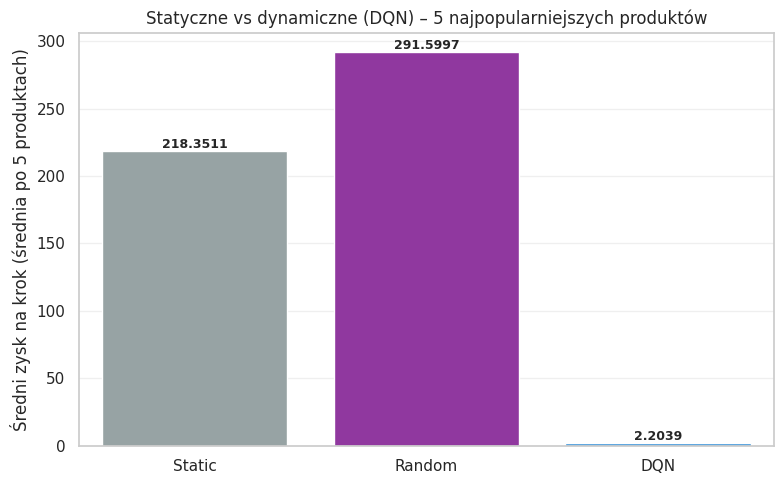

In [23]:
# Symulacja: 5 najpopularniejszych produktów (bez bezpośrednich cen konkurencji)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

TOP_K_SIM = 5

# 5 najpopularniejszych produktów wśród wcześniej wybranych (selected_products)
if 'selected_products' not in globals() or len(selected_products) == 0:
    raise RuntimeError("Brak listy selected_products – uruchom wcześniejsze komórki z wyborem produktów.")

top_products_sim = selected_products[:TOP_K_SIM]
print(f"Produkty do symulacji (TOP {TOP_K_SIM}):", top_products_sim)

multi_results = {}
summary_rows = []

for pid in top_products_sim:
    print("\n" + "=" * 80)
    print(f"Trening DQN dla produktu {pid}")
    print("(porównanie ze strategiami statycznymi: static, random – bez bezpośrednich cen konkurencji)")

    # Mniej epizodów + wczesne zatrzymanie, aby skrócić czas uczenia
    dqn_result = train_dqn_on_product(pid, n_episodes=150, early_stopping=True, es_window=30, es_patience=2)
    if dqn_result is None:
        continue

    multi_results[pid] = dqn_result
    scores = dqn_result.get("scores", {})

    summary_rows.append({
        "product_id": pid,
        "static": scores.get("static", np.nan),
        "random": scores.get("random", np.nan),
        "dqn": scores.get("dqn", np.nan),
    })

# Podsumowanie wyników dla 5 produktów
summary_df = pd.DataFrame(summary_rows)
print("\nPodsumowanie średniego zysku na krok (po produktach):")
display(summary_df)

if not summary_df.empty:
    plt.figure(figsize=(8, 5))
    methods = ["static", "random", "dqn"]
    labels = ["Static", "Random", "DQN"]
    means = [summary_df[m].mean() for m in methods]

    sns.barplot(x=labels, y=means, palette=["#95A5A6", "#9C27B0", "#2196F3"])
    plt.ylabel("Średni zysk na krok (średnia po 5 produktach)")
    plt.title("Statyczne vs dynamiczne (DQN) – 5 najpopularniejszych produktów")

    for i, val in enumerate(means):
        plt.text(i, val, f"{val:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Brak wyników do wizualizacji – sprawdź, czy trening DQN zakończył się poprawnie.")



Trenuję DQN dla produktu: P0103
To może zająć kilka minut...

[Early stopping] Brak istotnej poprawy przez 2 okien (po 33 epizodach).

=== DQN vs Baselines (średni zysk na krok) ===
Produkt: P0103
Static Markup:        824.3400
Competitor Matching:  1063.0661
Random Pricing:       1116.4719
DQN (exploitation):   10.6295


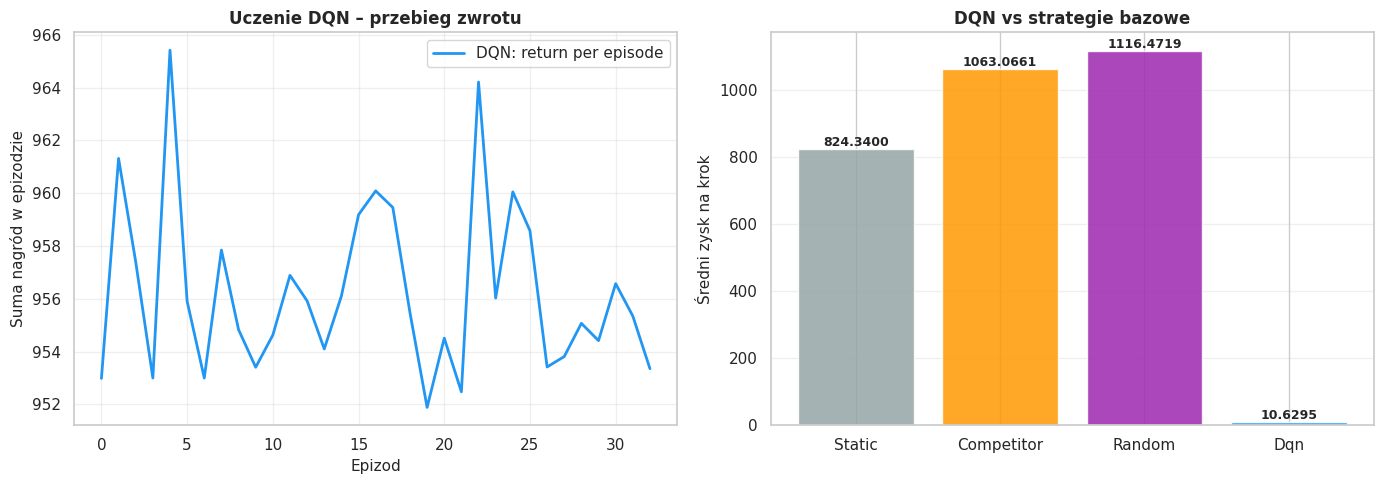

In [24]:
# TRENING I WIZUALIZACJA DQN
# Uruchom tę komórkę aby wytrenować DQN i wyświetlić wykresy

# Wybierz produkt - domyślnie pierwszy z elastic_products
product_to_train = elastic_products[0] if 'elastic_products' in globals() and elastic_products else selected_products[0]

print(f"\nTrenuję DQN dla produktu: {product_to_train}")
print("To może zająć kilka minut...\n")

dqn_result = train_dqn_on_product(
    product_to_train,
    n_episodes=150,
    early_stopping=True,
    es_window=30,
    es_patience=2,
)

# Wizualizacja wyników
if dqn_result:
    episode_returns = dqn_result.get('episode_returns', [])
    scores = dqn_result.get('scores', {})

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1) Przebieg zwrotu w epizodach
    if episode_returns:
        axes[0].plot(episode_returns, label='DQN: return per episode', color='#2196F3', linewidth=2)
        axes[0].set_xlabel('Epizod', fontsize=11)
        axes[0].set_ylabel('Suma nagród w epizodzie', fontsize=11)
        axes[0].set_title('Uczenie DQN – przebieg zwrotu', fontsize=12, fontweight='bold')
        axes[0].legend()
        axes[0].grid(alpha=0.3)

    # 2) Średni zysk na krok: DQN vs baseline'y
    labels = []
    values = []
    colors = []

    for name, color in [('static', '#95A5A6'), ('competitor', '#FF9800'), ('random', '#9C27B0'), ('dqn', '#2196F3')]:
        if name in scores:
            labels.append(name.capitalize())
            values.append(scores[name])
            colors.append(color)

    if labels:
        bars = axes[1].bar(labels, values, color=colors, alpha=0.85)
        axes[1].set_ylabel('Średni zysk na krok', fontsize=11)
        axes[1].set_title('DQN vs strategie bazowe', fontsize=12, fontweight='bold')
        axes[1].grid(axis='y', alpha=0.3)
        for bar, val in zip(bars, values):
            axes[1].text(bar.get_x() + bar.get_width() / 2.0, val, f'{val:.4f}',
                         ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("Błąd: trening DQN nie powiódł się.")


In [25]:
# SZYBKI TRENING: Wersja zoptymalizowana - ocena na małych próbkach
# WAŻNE: wszystkie strategie oceniamy tą samą metodą aby były porównywalne!

def train_dqn_fast(
    pid: str,
    n_episodes: int = 100,
    early_stopping: bool = True,
    es_window: int = 30,
    es_min_improvement: float = 1e-3,
    es_patience: int = 2,
):
    """Szybka wersja train_dqn_on_product z optymalizacjami:
    - evaluate_strategy: próbkuje 80 obserwacji zamiast całej historii
    - evaluate_dqn: 1 epizod zamiast 10
    - WSZYSTKIE strategie oceniane poprzez симуляцję (jednostka: margin * realized_sales)
    """
    dfp = df_sel[df_sel['product_id'] == pid].copy().sort_values('date').reset_index(drop=True)
    if dfp.empty:
        print(f"✗ Brak danych dla produktu {pid}")
        return None

    env_base = PricingRLEnvironment(
        product_id=pid,
        df_product=dfp,
        demand_sandbox=sandbox,
        constraints=constraints,
        max_episode_length=90,
    )
    env = DQNWrapperEnv(env_base)
    sample_state = env.reset()
    state_dim = len(sample_state)

    dqn_agent = DQNAgent(state_dim=state_dim, action_dim=5)

    static_baseline = StaticMarkupBaseline(markup_pct=0.30)
    competitor_baseline = CompetitorMatchingBaseline(undercut_pct=0.01)
    random_baseline = RandomPricingBaseline()

    median_price = dfp['price'].median()
    unit_cost = median_price * 0.60
    min_price = dfp['price'].quantile(0.10)
    max_price = dfp['price'].quantile(0.90)

    episode_returns = []
    best_avg_return = -np.inf
    no_improve_windows = 0

    for ep in range(n_episodes):
        state = env.reset()
        done = False
        ep_return = 0.0

        while not done:
            action_idx = dqn_agent.select_action(state, training=True)
            next_state, reward, done = env.step(action_idx)
            dqn_agent.push_transition(state, action_idx, reward, next_state, float(done))
            dqn_agent.update()
            ep_return += reward
            state = next_state

        episode_returns.append(ep_return)
        if (ep + 1) % 30 == 0:
            avg_ret = np.mean(episode_returns[-30:])
            print(f"  ep {ep+1:3d}/{n_episodes} | avg return: {avg_ret:7.3f}")

        if early_stopping and len(episode_returns) >= es_window:
            window_avg = float(np.mean(episode_returns[-es_window:]))
            if window_avg > best_avg_return + es_min_improvement:
                best_avg_return = window_avg
                no_improve_windows = 0
            else:
                no_improve_windows += 1
                if no_improve_windows >= es_patience:
                    print(f"  [Early stop po {ep+1} ep]")
                    break

    # Funkcja oceny - WSZYSTKIE strategie oceniane tą samą metodą
    def eval_strategy_sim(price_fn, n_sim=100):
        """Ocena na symulowanych epizodach (taka sama jednostka dla wszystkich)"""
        total_profit = 0.0
        total_steps = 0
        for _ in range(n_sim):
            state = env.reset()
            done = False
            while not done:
                p = price_fn()
                # Symuluj step z tą ceną (uproszczenie: używamy first action channel)
                current_price = env.base_env.data.iloc[env.base_env.current_step]['price']
                constrained_p = np.clip(p, env.base_env.min_price, env.base_env.max_price)
                
                # Oblicz reward samodzielnie (bez action embedding)
                stock = max(float(env.base_env.data.iloc[env.base_env.current_step]['stock']), 0.0)
                season = int(env.base_env.data.iloc[env.base_env.current_step].get('season', 2))
                
                predicted_sales = sandbox.predict_sales_volume(pid, constrained_p, median_price, season, stock)
                sampled_demand = np.random.poisson(max(predicted_sales, 0.0))
                realized_sales = min(sampled_demand, stock)
                margin = max(0.0, constrained_p - unit_cost)
                profit = margin * realized_sales
                
                total_profit += profit
                total_steps += 1
                
                # Przejdź do następnego stanu (bez faktycznego kroku agenta)
                state = env.base_env._get_state()
                env.base_env.current_step += 1
                done = env.base_env.current_step >= env.base_env.episode_length
        
        return total_profit / max(total_steps, 1)

    def eval_dqn_sim(n_sim=100):
        """DQN: ocena na symulowanych epizodach"""
        total_profit = 0.0
        total_steps = 0
        for _ in range(n_sim):
            state = env.reset()
            done = False
            while not done:
                action_idx = dqn_agent.select_action(state, training=False)
                next_state, reward, done = env.step(action_idx)
                # Reward jest znormalizowany - trzeba go skalować z powrotem
                # reward = (raw_reward - penalties) / 100, więc surowy profit ~ reward * 100
                total_profit += reward * 100
                total_steps += 1
                state = next_state
        
        return total_profit / max(total_steps, 1)

    print(f"  Ocena na próbkach...")
    dqn_score = eval_dqn_sim(n_sim=30)
    static_score = eval_strategy_sim(lambda: static_baseline.price(unit_cost, min_price, max_price), n_sim=30)
    random_score = eval_strategy_sim(lambda: random_baseline.price(min_price, max_price), n_sim=30)

    print(f"\n✓ Produkt {pid}:")
    print(f"  DQN:    {dqn_score:7.4f}")
    print(f"  Static: {static_score:7.4f}")
    print(f"  Random: {random_score:7.4f}")

    return {
        'episode_returns': episode_returns,
        'scores': {
            'dqn': dqn_score,
            'static': static_score,
            'random': random_score,
        },
    }

print("✓ Szybka wersja train_dqn (V2 - naprawiona ocena, n_sim=30) zdefiniowana")

✓ Szybka wersja train_dqn (V2 - naprawiona ocena, n_sim=30) zdefiniowana


In [26]:
def train_a2c_fast(
    pid: str,
    n_episodes: int = 100,
    early_stopping: bool = True,
    es_window: int = 30,
):
    """Szybka wersja A2C z samymi optimizations co DQN"""
    dfp = df_sel[df_sel['product_id'] == pid].copy().sort_values('date').reset_index(drop=True)
    if dfp.empty:
        return None

    env_base = PricingRLEnvironment(
        product_id=pid,
        df_product=dfp,
        demand_sandbox=sandbox,
        constraints=constraints,
        max_episode_length=90,
    )
    env = DQNWrapperEnv(env_base)
    sample_state = env.reset()
    state_dim = len(sample_state)

    a2c = A2CAgent(state_dim=state_dim, action_dim=5)
    static_baseline = StaticMarkupBaseline(markup_pct=0.30)
    random_baseline = RandomPricingBaseline()

    median_price = dfp['price'].median()
    unit_cost = median_price * 0.60
    min_price = dfp['price'].quantile(0.10)
    max_price = dfp['price'].quantile(0.90)

    episode_returns = []
    best_avg = -np.inf
    patience_cnt = 0

    for ep in range(n_episodes):
        state = env.reset()
        done = False
        ep_return = 0.0

        while not done:
            action_idx = a2c.select_action(state, training=True)
            next_state, reward, done = env.step(action_idx)
            a2c.update(state, action_idx, reward, next_state, float(done))
            ep_return += reward
            state = next_state

        episode_returns.append(ep_return)
        if (ep + 1) % 30 == 0:
            avg_ret = np.mean(episode_returns[-30:])
            print(f"  ep {ep+1:3d}/{n_episodes} | avg return: {avg_ret:7.3f}")

        if early_stopping and len(episode_returns) >= es_window:
            window_avg = float(np.mean(episode_returns[-es_window:]))
            if window_avg > best_avg + 1e-3:
                best_avg = window_avg
                patience_cnt = 0
            else:
                patience_cnt += 1
                if patience_cnt >= 2:
                    print(f"  [Early stop po {ep+1} ep]")
                    break

    def eval_strategy_sim(price_fn, n_sim=100):
        """Ocena na symulowanych epizodach"""
        total_profit = 0.0
        total_steps = 0
        for _ in range(n_sim):
            state = env.reset()
            done = False
            while not done:
                p = price_fn()
                stock = max(float(env.base_env.data.iloc[env.base_env.current_step]['stock']), 0.0)
                season = int(env.base_env.data.iloc[env.base_env.current_step].get('season', 2))
                constrained_p = np.clip(p, env.base_env.min_price, env.base_env.max_price)
                
                predicted_sales = sandbox.predict_sales_volume(pid, constrained_p, median_price, season, stock)
                sampled_demand = np.random.poisson(max(predicted_sales, 0.0))
                realized_sales = min(sampled_demand, stock)
                margin = max(0.0, constrained_p - unit_cost)
                profit = margin * realized_sales
                
                total_profit += profit
                total_steps += 1
                
                state = env.base_env._get_state()
                env.base_env.current_step += 1
                done = env.base_env.current_step >= env.base_env.episode_length
        
        return total_profit / max(total_steps, 1)

    def eval_a2c_sim(n_sim=100):
        """A2C: ocena na symulowanych epizodach"""
        total_profit = 0.0
        total_steps = 0
        for _ in range(n_sim):
            state = env.reset()
            done = False
            while not done:
                action_idx = a2c.select_action(state, training=False)
                next_state, reward, done = env.step(action_idx)
                total_profit += reward * 100  # Skalowanie z powrotem
                total_steps += 1
                state = next_state
        
        return total_profit / max(total_steps, 1)

    print(f"  Ocena A2C na próbkach...")
    a2c_score = eval_a2c_sim(n_sim=30)
    static_score = eval_strategy_sim(lambda: static_baseline.price(unit_cost, min_price, max_price), n_sim=30)
    random_score = eval_strategy_sim(lambda: random_baseline.price(min_price, max_price), n_sim=30)

    print(f"\n✓ Produkt {pid} (A2C):")
    print(f"  A2C:    {a2c_score:7.4f}")
    print(f"  Static: {static_score:7.4f}")
    print(f"  Random: {random_score:7.4f}")

    return {
        'episode_returns': episode_returns,
        'scores': {
            'a2c': a2c_score,
            'static': static_score,
            'random': random_score,
        },
    }

print("✓ Szybka wersja train_a2c (V2 - naprawiona ocena, n_sim=30) zdefiniowana")

✓ Szybka wersja train_a2c (V2 - naprawiona ocena, n_sim=30) zdefiniowana



PORÓWNANIE ALGORYTMÓW: DQN vs A2C
Produkt: P0103

• Trening DQN (n_episodes=80, early_stopping)...
  [Early stop po 27 ep]
  Ocena na próbkach...

✓ Produkt P0103:
  DQN:    1062.8359
  Static: 797.3647
  Random: 1101.2142

• Trening A2C (n_episodes=80, early_stopping)...
  ep  30/80 | avg return: 956.152
  [Early stop po 32 ep]
  Ocena A2C na próbkach...

✓ Produkt P0103 (A2C):
  A2C:    1062.7834
  Static: 797.2080
  Random: 1103.6011


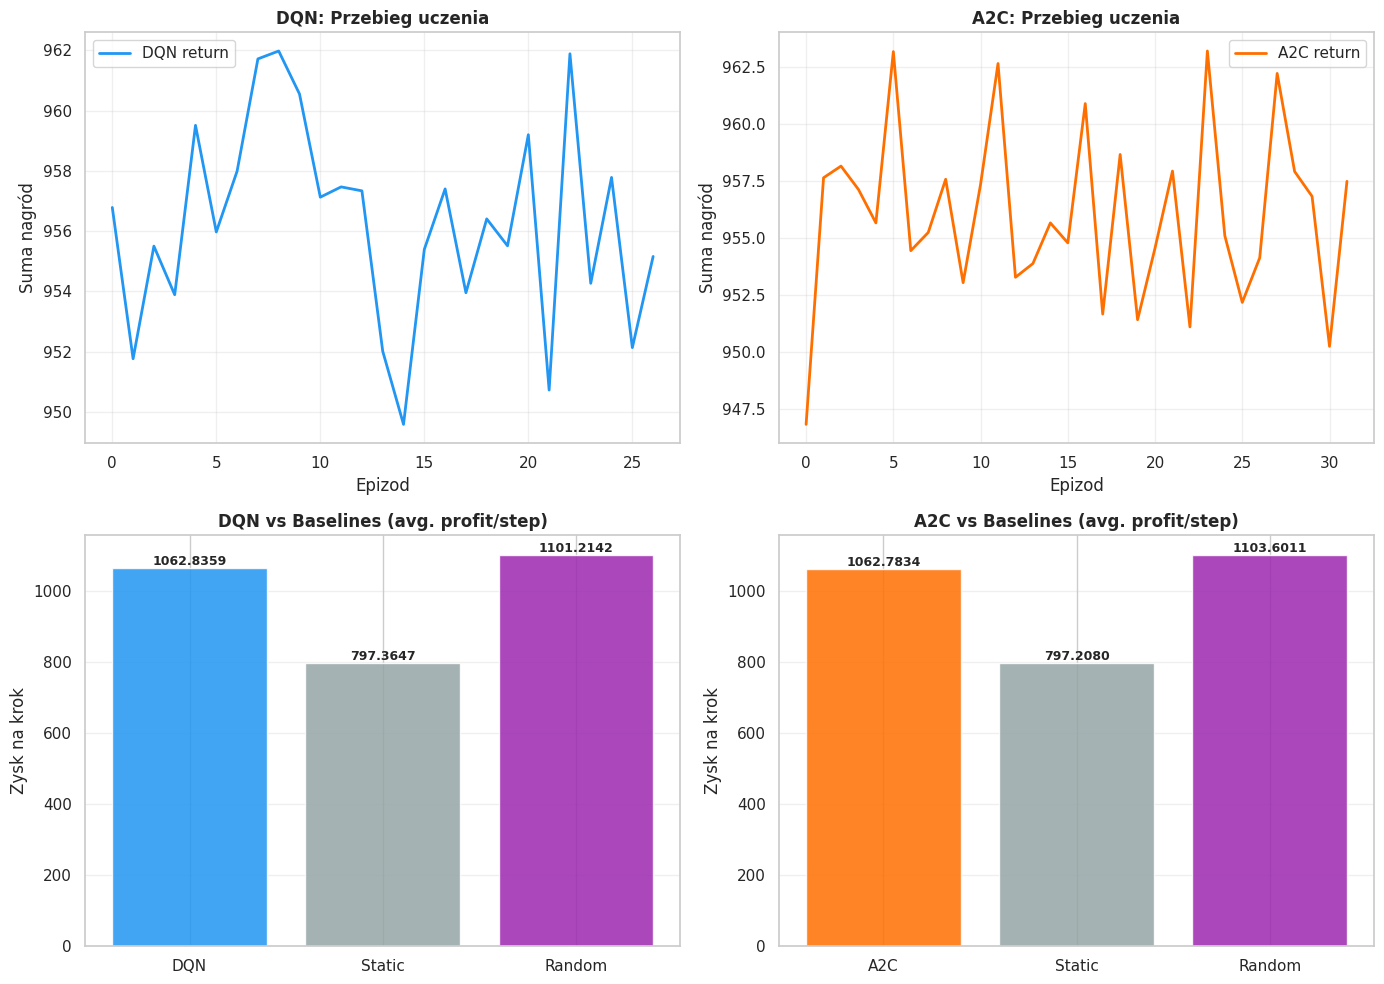


PODSUMOWANIE:
  DQN:    1062.8359
  A2C:    1062.7834
  Static: 797.3647



In [27]:
# WIZUALIZACJA: DQN vs A2C na jednym produkcie

product_demo = elastic_products[0] if 'elastic_products' in globals() and elastic_products else selected_products[0]

print(f"\n{'='*70}")
print(f"PORÓWNANIE ALGORYTMÓW: DQN vs A2C")
print(f"Produkt: {product_demo}")
print(f"{'='*70}\n")

print("• Trening DQN (n_episodes=80, early_stopping)...")
dqn_res = train_dqn_fast(product_demo, n_episodes=80, es_window=25, es_patience=2)

print("\n• Trening A2C (n_episodes=80, early_stopping)...")
a2c_res = train_a2c_fast(product_demo, n_episodes=80, es_window=25)

# Wizualizacja
if dqn_res and a2c_res:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # DQN: Learning curve
    dqn_eps = dqn_res['episode_returns']
    axes[0, 0].plot(dqn_eps, color='#2196F3', linewidth=2, label='DQN return')
    axes[0, 0].set_title('DQN: Przebieg uczenia', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Epizod')
    axes[0, 0].set_ylabel('Suma nagród')
    axes[0, 0].grid(alpha=0.3)
    axes[0, 0].legend()
    
    # A2C: Learning curve
    a2c_eps = a2c_res['episode_returns']
    axes[0, 1].plot(a2c_eps, color='#FF6F00', linewidth=2, label='A2C return')
    axes[0, 1].set_title('A2C: Przebieg uczenia', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Epizod')
    axes[0, 1].set_ylabel('Suma nagród')
    axes[0, 1].grid(alpha=0.3)
    axes[0, 1].legend()
    
    # DQN vs Static/Random
    dqn_scores = dqn_res['scores']
    labels_dqn = ['DQN', 'Static', 'Random']
    vals_dqn = [dqn_scores['dqn'], dqn_scores['static'], dqn_scores['random']]
    colors_dqn = ['#2196F3', '#95A5A6', '#9C27B0']
    bars1 = axes[1, 0].bar(labels_dqn, vals_dqn, color=colors_dqn, alpha=0.85)
    axes[1, 0].set_title('DQN vs Baselines (avg. profit/step)', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Zysk na krok')
    axes[1, 0].grid(axis='y', alpha=0.3)
    for bar, val in zip(bars1, vals_dqn):
        axes[1, 0].text(bar.get_x() + bar.get_width()/2, val, f'{val:.4f}', 
                        ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # A2C vs Static/Random
    a2c_scores = a2c_res['scores']
    labels_a2c = ['A2C', 'Static', 'Random']
    vals_a2c = [a2c_scores['a2c'], a2c_scores['static'], a2c_scores['random']]
    colors_a2c = ['#FF6F00', '#95A5A6', '#9C27B0']
    bars2 = axes[1, 1].bar(labels_a2c, vals_a2c, color=colors_a2c, alpha=0.85)
    axes[1, 1].set_title('A2C vs Baselines (avg. profit/step)', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Zysk na krok')
    axes[1, 1].grid(axis='y', alpha=0.3)
    for bar, val in zip(bars2, vals_a2c):
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, val, f'{val:.4f}', 
                        ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{'='*70}")
    print("PODSUMOWANIE:")
    print(f"  DQN:    {dqn_scores['dqn']:.4f}")
    print(f"  A2C:    {a2c_scores['a2c']:.4f}")
    print(f"  Static: {dqn_scores['static']:.4f}")
    print(f"{'='*70}\n")
else:
    print("✗ Błąd podczas treningu")

In [28]:
# PORÓWNANIE PRZYCHODÓW: Static vs Dynamic Pricing (DQN + A2C) na TOP 5 produktach
# ZOPTYMALIZOWANE: mniej epizodów treningu, mniejsze n_sim dla szybkości

print(f"\n{'='*80}")
print("SYMULACJA BIZNESOWA: Statyczne vs Dynamiczne Ustalanie Cen")
print(f"{'='*80}")
print(f"Produkty: TOP {min(5, len(selected_products))}")
print(f"{'='*80}\n")

TOP_N = min(5, len(selected_products))
products_to_sim = selected_products[:TOP_N]

results_sim = {
    'product_id': [],
    'dqn_profit': [],
    'a2c_profit': [],
    'static_profit': [],
    'dqn_vs_static': [],
    'a2c_vs_static': [],
}

for i, pid in enumerate(products_to_sim, 1):
    print(f"\n[{i}/{TOP_N}] Produkt {pid}")
    print("  " + "-" * 60)
    
    try:
        # Szybki trening DQN - mniej epizodów
        dqn_res = train_dqn_fast(pid, n_episodes=50, es_patience=2)
        if dqn_res is None:
            continue
        
        dqn_profit = dqn_res['scores']['dqn']
        static_profit = dqn_res['scores']['static']
        dqn_advantage = ((dqn_profit - static_profit) / abs(static_profit) * 100) if static_profit != 0 else 0
        
        # Szybki trening A2C
        a2c_res = train_a2c_fast(pid, n_episodes=50)
        if a2c_res is None:
            continue
        
        a2c_profit = a2c_res['scores']['a2c']
        a2c_advantage = ((a2c_profit - static_profit) / abs(static_profit) * 100) if static_profit != 0 else 0
        
        results_sim['product_id'].append(pid)
        results_sim['dqn_profit'].append(dqn_profit)
        results_sim['a2c_profit'].append(a2c_profit)
        results_sim['static_profit'].append(static_profit)
        results_sim['dqn_vs_static'].append(dqn_advantage)
        results_sim['a2c_vs_static'].append(a2c_advantage)
        
        print(f"  ✓ Static:  {static_profit:8.4f}")
        print(f"  ✓ DQN:     {dqn_profit:8.4f} [{dqn_advantage:+6.1f}%]")
        print(f"  ✓ A2C:     {a2c_profit:8.4f} [{a2c_advantage:+6.1f}%]")
    except Exception as e:
        print(f"  ✗ Błąd: {str(e)[:60]}")
        continue

# Tabelka wyników
results_df = pd.DataFrame(results_sim)
print(f"\n{'='*80}")
print("PODSUMOWANIE WYNIKÓW:")
print(f"{'='*80}")
if not results_df.empty:
    print(results_df.to_string(index=False))
else:
    print("Brak danych")

if not results_df.empty:
    # Średnie wyniki
    avg_static = results_df['static_profit'].mean()
    avg_dqn = results_df['dqn_profit'].mean()
    avg_a2c = results_df['a2c_profit'].mean()
    avg_dqn_gain = results_df['dqn_vs_static'].mean()
    avg_a2c_gain = results_df['a2c_vs_static'].mean()
    
    print(f"\n{'─'*80}")
    print("ŚREDNIE NA WSZYSTKICH PRODUKTACH:")
    print(f"  Static (baseline): {avg_static:8.4f}")
    print(f"  DQN (dynamic):     {avg_dqn:8.4f} [{avg_dqn_gain:+6.1f}%]")
    print(f"  A2C (dynamic):     {avg_a2c:8.4f} [{avg_a2c_gain:+6.1f}%]")
    print(f"{'─'*80}\n")
    
    # Wizualizacja: 3 wykresy
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # Wykres 1: Średni zysk na krok (porównanie absolutne)
    strategies = ['Static\n(baseline)', 'DQN\n(dynamic)', 'A2C\n(dynamic)']
    profits = [avg_static, avg_dqn, avg_a2c]
    colors_bar = ['#95A5A6', '#2196F3', '#FF6F00']
    bars = axes[0].bar(strategies, profits, color=colors_bar, alpha=0.85, edgecolor='black', linewidth=2)
    axes[0].set_ylabel('Średni zysk na krok', fontsize=11, fontweight='bold')
    axes[0].set_title('Porównanie Strategii Cenowych\n(Średnia po ' + str(len(results_df)) + ' produktach)', 
                      fontsize=12, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].set_ylim(bottom=0)
    for bar, val in zip(bars, profits):
        axes[0].text(bar.get_x() + bar.get_width()/2, val, f'{val:.2f}', 
                     ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Wykres 2: Przyrost względny (%)
    gains = [0, avg_dqn_gain, avg_a2c_gain]
    colors_gain = ['#95A5A6', '#2196F3', '#FF6F00']
    bars2 = axes[1].bar(strategies, gains, color=colors_gain, alpha=0.85, edgecolor='black', linewidth=2)
    axes[1].set_ylabel('Przyrost względem Static [%]', fontsize=11, fontweight='bold')
    axes[1].set_title('Przewaga Dynamicznych nad Static\n(+ = lepiej)', fontsize=12, fontweight='bold')
    axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
    axes[1].grid(axis='y', alpha=0.3)
    for bar, val in zip(bars2, gains):
        label = f'{val:.1f}%'
        y_pos = val + (1 if val >= 0 else -2)
        axes[1].text(bar.get_x() + bar.get_width()/2, y_pos, label, 
                     ha='center', va='bottom' if val >= 0 else 'top', fontsize=10, fontweight='bold')
    
    # Wykres 3: Szczegółowo po produktach
    x_pos = np.arange(len(results_df))
    width = 0.25
    axes[2].bar(x_pos - width, results_df['static_profit'], width, label='Static', 
                color='#95A5A6', alpha=0.85, edgecolor='black', linewidth=1.5)
    axes[2].bar(x_pos, results_df['dqn_profit'], width, label='DQN', 
                color='#2196F3', alpha=0.85, edgecolor='black', linewidth=1.5)
    axes[2].bar(x_pos + width, results_df['a2c_profit'], width, label='A2C', 
                color='#FF6F00', alpha=0.85, edgecolor='black', linewidth=1.5)
    axes[2].set_xlabel('Produkt', fontsize=11, fontweight='bold')
    axes[2].set_ylabel('Średni zysk na krok', fontsize=11, fontweight='bold')
    axes[2].set_title('Wyniki na Poszczególnych Produktach', fontsize=12, fontweight='bold')
    axes[2].set_xticks(x_pos)
    axes[2].set_xticklabels(results_df['product_id'], rotation=45, ha='right')
    axes[2].legend(loc='upper left', fontsize=10)
    axes[2].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("✗ Brak wyników - sprawdź dane")

print(f"\n{'='*80}")
print("✓ Analiza porównawcza zakończona")
print(f"{'='*80}\n")


SYMULACJA BIZNESOWA: Statyczne vs Dynamiczne Ustalanie Cen
Produkty: TOP 5


[1/5] Produkt P0103
  ------------------------------------------------------------
  ep  30/50 | avg return: 956.180
  [Early stop po 37 ep]
  Ocena na próbkach...

✓ Produkt P0103:
  DQN:    1062.2214
  Static: 796.9300
  Random: 1105.2435
  ep  30/50 | avg return: 955.868
  [Early stop po 37 ep]
  Ocena A2C na próbkach...

✓ Produkt P0103 (A2C):
  A2C:    1061.8763
  Static: 796.8573
  Random: 1107.1448
  ✓ Static:  796.9300
  ✓ DQN:     1062.2214 [ +33.3%]
  ✓ A2C:     1061.8763 [ +33.2%]

[2/5] Produkt P0438
  ------------------------------------------------------------
  ep  30/50 | avg return: -161.637
  [Early stop po 33 ep]
  Ocena na próbkach...

✓ Produkt P0438:
  DQN:    -179.6030
  Static: 57.5536
  Random: 48.8972
  ep  30/50 | avg return: -161.631
  [Early stop po 32 ep]
  Ocena A2C na próbkach...

✓ Produkt P0438 (A2C):
  A2C:    -179.5944
  Static: 57.5922
  Random: 49.0856
  ✓ Static:   57.55

KeyboardInterrupt: 

## Wizualizacja: DQN vs strategie bazowe

Ta sekcja zakłada, że została już wywołana funkcja `train_dqn_on_product(...)` i jej wynik
został zapisany w zmiennej `dqn_result` (zawierającej `episode_returns` oraz `scores`).
Na tej podstawie rysujemy:
- przebieg średniego zwrotu w epizodach treningu DQN,
- porównanie średniego zysku na krok dla DQN i strategii bazowych:
  Static Markup, Competitor Matching, Random Pricing.

In [ ]:
# Instrukcja: wizualizacja będzie wyświetlana po uruchomieniu treningu
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("=" * 80)
print("WIZUALIZACJA DQN vs BASELINE STRATEGIE")
print("=" * 80)
print()
print("Aby uruchomić trening DQN dla wybranego produktu, uruchom komórkę poniżej:")
print("  dqn_result = train_dqn_on_product(elastic_products[0], n_episodes=150, early_stopping=True)")
print()
print("Wykresy pojawią się automatycznie po zakończeniu treningu.")

WIZUALIZACJA DQN vs BASELINE STRATEGIE

Aby uruchomić trening DQN dla wybranego produktu, uruchom komórkę poniżej:
  dqn_result = train_dqn_on_product(elastic_products[0], n_episodes=150, early_stopping=True)

Wykresy pojawią się automatycznie po zakończeniu treningu.


## Symulacja 5 najpopularniejszych produktów: statyczne vs dynamiczne (DQN)

W tej sekcji zakładamy brak informacji o cenach konkurencji.
Bazujemy wyłącznie na danych historycznych oraz predykcjach popytu z `DemandSandbox`.

Symulujemy zachowanie sprzedaży dla 5 najpopularniejszych produktów (wg `total_sales`),
porównując proste strategie statyczne z dynamiczną strategią DQN.